### Perspective Transformation using OpenCV

Perspective transformation allows you to change the perspective of a given image or image region. It maps the points from a quadrilateral in the source image to a quadrilateral in the destination image.

Here's how the code works:

1.  **Load the Image**: Reads an image from a specified path.
2.  **Define Source Points (`pts1`)**: These are the four corner points (in order: top-left, top-right, bottom-right, bottom-left) of the region in the *original image* that you want to transform.
3.  **Define Destination Points (`pts2`)**: These are the four corresponding corner points in the *output image* where the `pts1` region will be mapped. The `width` and `height` of the output image are defined based on these points.
4.  **Calculate Transformation Matrix (`M`)**: `cv2.getPerspectiveTransform` computes the 3x3 transformation matrix from the source and destination points.
5.  **Apply Transformation**: `cv2.warpPerspective` applies this transformation matrix to the original image to create the warped output image.
6.  **Display Images**: The original and transformed images are displayed for comparison.

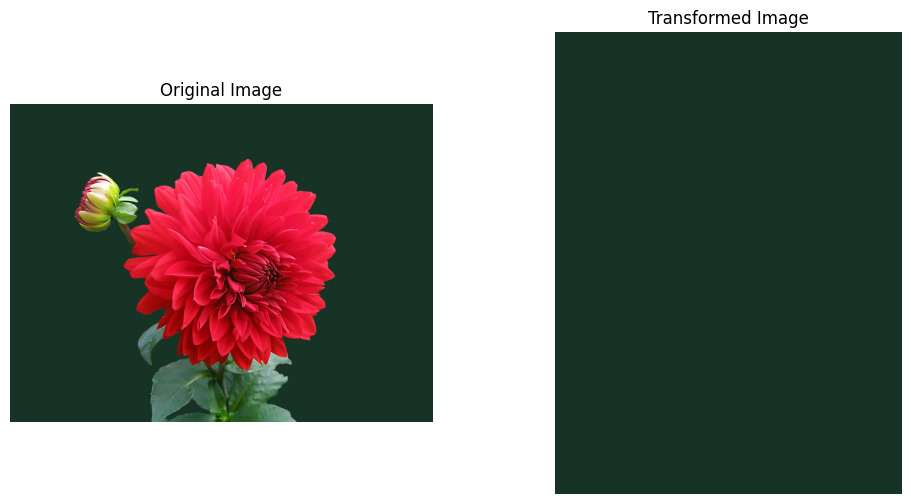

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Create a dummy image for demonstration if no image is provided
# In a real scenario, you would load your image here.
try:
    # Attempt to load a common image in Colab, or assume it exists
    # For a real case, replace this with your actual image path
    image_path = '/content/image.jpg' # Updated path to use the uploaded image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}. Creating a dummy image.")
except FileNotFoundError:
    # Create a simple dummy image if not found or on Colab
    width, height = 400, 300
    img = np.zeros((height, width, 3), np.uint8)
    cv2.rectangle(img, (50, 50), (350, 250), (0, 255, 0), -1) # Green rectangle
    cv2.circle(img, (100, 100), 30, (0, 0, 255), -1) # Red circle
    cv2.putText(img, 'Original', (150, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

# Check if the image was loaded/created successfully
if img is None:
    print("Error: Could not load or create image. Please check the image path or provide a valid image.")
else:
    rows, cols, ch = img.shape

    # Define the 4 points on the original image (e.g., corners of a rectangle)
    # These points should be in order: top-left, top-right, bottom-right, bottom-left
    pts1 = np.float32([
        [50, 50],    # Top-left
        [350, 50],   # Top-right
        [350, 250],  # Bottom-right
        [50, 250]    # Bottom-left
    ])

    # Define the 4 corresponding points in the output image
    # This defines the new perspective. Adjust these values to change the transformation.
    output_width = 300
    output_height = 400

    pts2 = np.float32([
        [0, 0],              # New Top-left
        [output_width - 1, 0],       # New Top-right
        [output_width - 1, output_height - 1], # New Bottom-right
        [0, output_height - 1]       # New Bottom-left
    ])

    # Get the perspective transformation matrix
    M = cv2.getPerspectiveTransform(pts1, pts2)

    # Apply the perspective transformation to the image
    # The third argument is the size of the output image (width, height)
    dst = cv2.warpPerspective(img, M, (output_width, output_height))

    # Convert images from BGR to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

    # Display the original and transformed images
    plt.figure(figsize=(12, 6))

    plt.subplot(121)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(dst_rgb)
    plt.title('Transformed Image')
    plt.axis('off')

    plt.show()
